## Bayesian Modelling of Extreme Flows According for Physical-Geographic Features in Vistula Basin

Paweł Jerzyna, Piotr Grzyb

In [2]:
import os
import sys
import glob
import re
from pathlib import Path
import folium

from cmdstanpy import CmdStanModel

import arviz as az
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path(os.getcwd())
SCRIPTS_DIR = PROJECT_ROOT / "scripts"

DATASET_DIR = PROJECT_ROOT / "dataset"
DATASET_DIR_CLEAN = PROJECT_ROOT / "cleaned_dataset"
DATASET_DIR_TXT = DATASET_DIR_CLEAN / "txt_files"
DATASET_DIR_CSV = DATASET_DIR_CLEAN / "csv_files"

sys.path.append(str(PROJECT_ROOT))




# No module named 'nbfomrmat' error - fix this later
#from utils.notebook import run_notebook
#from utils.display import display_df, display_image
"""
ten folder utils jest podjerzany (stworzony przez czat)
jak chcestawiac docker, to chociaz aby byl on dobzre zrobiony, a nie taki byle jaki
"""

/home/pawsooon/miniconda3/envs/data_analytics/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'\nten folder utils jest podjerzany (stworzony przez czat)\njak chcestawiac docker, to chociaz aby byl on dobzre zrobiony, a nie taki byle jaki\n'

## Czyszczenie danych: Ekstrakcja lat 2023-2025 z surowego datasetu do folderu dataset_cleaned

In [3]:
def clean_grdc_file(file_path, output_path):
    metadata = {
        "River": "Nieznana",
        "Station": "Nieznana",
        "Country": "Nieznany",
        "Latitude": "-999.000",
        "Longitude": "-999.000",
        "Catchment": "-999.00",
        "Altitude": "-999.00"
    }
    
    data_lines = []
    
    # Odczyt w kodowaniu 'latin-1' chroni przed błędem crashowania na jednostkach typu km²
    with open(file_path, 'r', encoding='latin-1') as f:
        lines = f.readlines()
        
    for i, line in enumerate(lines):
        stripped = line.strip()
        
        # Przetwarzanie linii nagłówkowych
        if stripped.startswith('#'):
            content = stripped[1:].strip()
            
            if "River:" in content:
                metadata["River"] = content.split("River:")[1].strip()
            elif "Station:" in content:
                metadata["Station"] = content.split("Station:")[1].strip()
            elif "Country:" in content:
                metadata["Country"] = content.split("Country:")[1].strip()
            elif "Latitude (DD):" in content:
                metadata["Latitude"] = content.split("Latitude (DD):")[1].strip()
            elif "Longitude (DD):" in content:
                metadata["Longitude"] = content.split("Longitude (DD):")[1].strip()
            elif "Catchment area" in content:
                val = content.split(":")[-1].strip()
                if not val and i + 1 < len(lines):
                    next_line = lines[i+1].strip()
                    if next_line.startswith('#'):
                        next_line = next_line[1:].strip()
                    if next_line and ';' not in next_line:
                        val = next_line
                metadata["Catchment"] = val if val else "-999.00"
            elif "Altitude (m ASL):" in content:
                metadata["Altitude"] = content.split("Altitude (m ASL):")[1].strip()
                
        # Przetwarzanie linii z pomiarami
        else:
            if ';' in stripped and not stripped.startswith('YYYY'):
                parts = stripped.split(';')
                if parts:
                    date_part = parts[0].strip()
                    try:
                        # Wyciągamy rok i filtrujemy pod kątem lat 2023, 2024, 2025
                        year = int(date_part.split('-')[0])
                        if year in [2023, 2024, 2025]:
                            data_lines.append(line.rstrip())
                    except (ValueError, IndexError):
                        pass

    # Jeśli stacja nie posiada danych z lat 2023-2025, nie generujemy pliku wyjściowego
    if not data_lines:
        return False
    
    # Budowanie struktury pliku tekstowego z zachowaniem idealnego wyrównania spacji
    output_lines = [
        f"River: {metadata['River']}",
        f"Station: {metadata['Station']}",
        f"Country: {metadata['Country']}",
        f"Latitude (DD):       {metadata['Latitude']}",
        f"Longitude (DD):      {metadata['Longitude']}",
        f"Catchment area (km²):      {metadata['Catchment']}",
        f"Altitude (m ASL):        {metadata['Altitude']}",
        "" # Pusta linia oddzielająca metadane od danych
    ]
    
    output_lines.extend(data_lines)
    
    # Zapis w bezpiecznym standardzie UTF-8
    with open(output_path, 'w', encoding='utf-8') as f:
        f.write('\n'.join(output_lines) + '\n')
        
    return True

# SZTYWNE USTAWIENIE ŚCIEŻEK - ODPORNE NA CONFIG Z INNYCH KOMÓREK
input_folder = PROJECT_ROOT / "dataset"
output_folder = PROJECT_ROOT / "dataset_cleaned"

if not input_folder.exists():
    print(f"❌ Błąd: Folder źródłowy '{input_folder}' nie istnieje!")
else:
    # Tworzenie nowego folderu docelowego
    output_folder.mkdir(parents=True, exist_ok=True)
        
    # Pobranie wszystkich plików pomijając pliki geojson lub inne śmieciowe
    all_files = [f for f in input_folder.glob('*') if f.is_file() and f.suffix != '.geojson']
    
    print(f"🚀 Rozpoczynam przetwarzanie... Znaleziono {len(all_files)} plików w folderze '{input_folder.name}'.")
    
    success = 0
    skipped = 0
    
    for file_path in all_files:
        # Zapis pod dokładnie taką samą nazwą pliku w nowym katalogu
        output_path = output_folder / file_path.name
        
        try:
            was_written = clean_grdc_file(file_path, output_path)
            if was_written:
                success += 1
            else:
                skipped += 1
        except Exception as e:
            print(f" -> Błąd w pliku {file_path.name}: {str(e)}")
            
    print("\n" + "="*50)
    print(f"✅ Sukces! Oczyszczono i zapisano: {success} plików.")
    print(f"ℹ️ Pominięto starych stacji:       {skipped} plików.")
    print(f"📁 Wyniki znajdziesz w folderze:    '{output_folder}'")
    print("="*50)

🚀 Rozpoczynam przetwarzanie... Znaleziono 85 plików w folderze 'dataset'.

✅ Sukces! Oczyszczono i zapisano: 69 plików.
ℹ️ Pominięto starych stacji:       16 plików.
📁 Wyniki znajdziesz w folderze:    '/home/pawsooon/Documents/Vsc/DA_project/dataset_cleaned'


## Czyszczenie danych: Krok 2 – Konwersja wyekstrahowanych plików TXT do płaskich tabel CSV (Oryginalne nazwy)

In [4]:
# Sztywne ustawienie ścieżek wejścia i wyjścia – niezależne od innych komórek
input_folder = PROJECT_ROOT / "dataset_cleaned"
output_folder = PROJECT_ROOT / "dataset_cleaned_csv"

if not input_folder.exists():
    print(f"❌ Błąd: Folder źródłowy '{input_folder}' nie istnieje! Upewnij się, że najpierw uruchomiłeś poprzednią komórkę.")
else:
    # Tworzymy nowy folder na pliki CSV
    output_folder.mkdir(parents=True, exist_ok=True)
        
    # Pobranie wszystkich plików tekstowych z folderu wyekstrahowanego
    files = [f for f in input_folder.glob('*') if f.is_file()]
    
    print(f"🚀 Rozpoczynam konwersję {len(files)} wyekstrahowanych plików TXT do formatu CSV...")
    
    success_count = 0
    error_count = 0
    
    for file_path in files:
        # Generujemy nową nazwę pliku z rozszerzeniem .csv (np. 6258250_Q_Day.Cmd.csv)
        csv_name = file_path.stem + '.csv'
        output_csv_path = output_folder / csv_name
        
        try:
            with open(file_path, 'r', encoding='utf-8') as f:
                lines = [line.strip() for line in f.readlines() if line.strip()]
                
            metadata = {}
            data_lines = []
            is_data = False
            
            # 1. Parsowanie struktury nagłówków tekstowych i wyodrębnienie linii danych
            for line in lines:
                if ":" in line and not is_data and ";" not in line:
                    key, val = line.split(":", 1)
                    metadata[key.strip()] = val.strip()
                else:
                    is_data = True
                    if ';' in line:
                        data_lines.append(line)
            
            parsed_rows = []
            
            # 2. Przetwarzanie rekordów i budowanie płaskiej struktury tabeli (metadane w każdym wierszu)
            for d_line in data_lines:
                parts = d_line.split(';')
                if len(parts) >= 3:
                    date = parts[0].strip()
                    time = parts[1].strip()
                    value = parts[2].strip()
                    
                    parsed_rows.append({
                        "River": metadata.get("River", "Nieznana"),
                        "Station": metadata.get("Station", "Nieznana"),
                        "Country": metadata.get("Country", "Nieznany"),
                        "Latitude_DD": metadata.get("Latitude (DD)", "-999.000"),
                        "Longitude_DD": metadata.get("Longitude (DD)", "-999.000"),
                        "Catchment_area_km2": metadata.get("Catchment area (km²)", "-999.00"),
                        "Altitude_m_ASL": metadata.get("Altitude (m ASL)", "-999.00"),
                        "Date": date,
                        "Time": time,
                        "Value": value
                    })
            
            # Zapisujemy do CSV – dane są już przefiltrowane, więc bierzemy cały wyekstrahowany pakiet
            if parsed_rows:
                df = pd.DataFrame(parsed_rows)
                df.to_csv(output_csv_path, index=False, encoding='utf-8-sig')
                success_count += 1
                
        except Exception as e:
            print(f" -> Błąd podczas konwersji pliku {file_path.name}: {str(e)}")
            error_count += 1

    # Końcowy raport operacji
    print("\n" + "="*50)
    print("📊 PODSUMOWANIE GENEROWANIA PLIKÓW CSV:")
    print(f"   • Konwersja udana (utworzono plików CSV): {success_count}")
    print(f"   • Błędy przetwarzania:                    {error_count}")
    print(f"📁 Wszystkie wygenerowane pliki znajdziesz w folderze: '{output_folder}'")
    print("="*50)

🚀 Rozpoczynam konwersję 69 wyekstrahowanych plików TXT do formatu CSV...

📊 PODSUMOWANIE GENEROWANIA PLIKÓW CSV:
   • Konwersja udana (utworzono plików CSV): 69
   • Błędy przetwarzania:                    0
📁 Wszystkie wygenerowane pliki znajdziesz w folderze: '/home/pawsooon/Documents/Vsc/DA_project/dataset_cleaned_csv'


## Czyszczenie danych: Krok 3 – Zmiana nazw plików CSV w miejscu (STACJA_RZEKA.csv)

In [5]:
def sanitize_filename(name):
    """Funkcja zamieniająca spacje na myślniki i usuwająca znaki niedozwolone w nazwach plików"""
    if not name or pd.isna(name):
        return "UNKNOWN"
    name = str(name).strip().replace(' ', '-')
    name = re.sub(r'[\\/*?:"<>|]', '', name)
    return name.upper()

# Sztywne ustawienie folderu docelowego - dokładnie tego, który powstał w Kroku 2
target_folder = PROJECT_ROOT / "dataset_cleaned_csv"

if not target_folder.exists():
    print(f"❌ Błąd: Folder z plikami CSV '{target_folder}' nie istnieje! Upewnij się, że poprzednia komórka wykonała się poprawnie.")
else:
    # Zczytujemy listę plików do pamięci jako listę obiektów Path, 
    # aby zmiana nazw w locie nie zaburzyła działania pętli (.glob)
    csv_files = [f for f in target_folder.glob('*.csv') if f.is_file()]
    
    print(f"🔄 Rozpoczynam zmianę nazw dla {len(csv_files)} plików CSV w folderze '{target_folder.name}'...")
    
    renamed_count = 0
    already_correct_count = 0
    skipped_count = 0
    error_count = 0
    
    for file_path in csv_files:
        try:
            # Czytamy tylko pierwszy wiersz pliku CSV, żeby wyciągnąć metadane (szybkie i oszczędne)
            df_head = pd.read_csv(file_path, nrows=1)
            
            if df_head.empty or 'Station' not in df_head.columns or 'River' not in df_head.columns:
                print(f"⚠️ Pomijam {file_path.name} - brak wymaganych kolumn 'Station' lub 'River'.")
                skipped_count += 1
                continue
            
            # Wyciągamy wartości z pierwszego wiersza
            station_raw = df_head['Station'].iloc[0]
            river_raw = df_head['River'].iloc[0]
            
            # Czyszczenie nazw stacji i rzek
            station_clean = sanitize_filename(station_raw)
            river_clean = sanitize_filename(river_raw)
            
            # Budujemy nową nazwę pliku
            new_name = f"{station_clean}_{river_clean}.csv"
            new_path = target_folder / new_name
            
            # Jeśli nazwa różni się od obecnej, zmieniamy ją fizycznie na dysku
            if file_path != new_path:
                # Zabezpieczenie: jeśli plik o takiej nazwie docelowej już istnieje, usuwamy go przed nadpisaniem
                if new_path.exists():
                    os.remove(new_path)
                
                # Zmiana nazwy w miejscu
                file_path.rename(new_path)
                print(f"✅ Zmieniono: {file_path.name} ➡️ {new_name}")
                renamed_count += 1
            else:
                already_correct_count += 1
                
        except Exception as e:
            print(f"❌ Błąd podczas przetwarzania {file_path.name}: {str(e)}")
            error_count += 1

    print("\n" + "="*50)
    print("📊 PODSUMOWANIE ZMIANY NAZW IN-PLACE:")
    print(f"   • Zmieniono nazw plików:         {renamed_count}")
    print(f"   • Pliki już poprawnie nazwane:   {already_correct_count}")
    print(f"   • Pominięto (błędna struktura):  {skipped_count}")
    print(f"   • Błędy wykonania:               {error_count}")
    print(f"📁 Wszystkie zaktualizowane pliki są w: '{target_folder}'")
    print("="*50)

🔄 Rozpoczynam zmianę nazw dla 138 plików CSV w folderze 'dataset_cleaned_csv'...
✅ Zmieniono: 6458090_Q_Day.Cmd.csv ➡️ PULAWY-AZOTY_VISTULA.csv
✅ Zmieniono: 6458130_Q_Day.Cmd.csv ➡️ WARSZAWA-NADWILANOWKA_VISTULA.csv
✅ Zmieniono: 6458420_Q_Day.Cmd.csv ➡️ WISLA_VISTULA.csv
✅ Zmieniono: 6458135_Q_Day.Cmd.csv ➡️ ZAMBSKI-KOSCIELNE_NAREV.csv
✅ Zmieniono: 6458030_Q_Day.Cmd.csv ➡️ JELEN_PRZEMSZA.csv
✅ Zmieniono: 6458025_Q_Day.Cmd.csv ➡️ PRZEMYSL_SAN.csv
✅ Zmieniono: 6458200_Q_Day.Cmd.csv ➡️ JORDANOW_SKAWA.csv
✅ Zmieniono: 6458525_Q_Day.Cmd.csv ➡️ NIETULISKO-DUZE_SWISLINA.csv
✅ Zmieniono: 6458809_Q_Day.Cmd.csv ➡️ MYSZYNIEC_ROZOGA.csv
✅ Zmieniono: 6458165_Q_Day.Cmd.csv ➡️ STREKOWA-GORA_NAREV.csv
✅ Zmieniono: 6458020_Q_Day.Cmd.csv ➡️ STARY-SACZ_POPRAD.csv
✅ Zmieniono: 6458620_Q_Day.Cmd.csv ➡️ CISNA_SOLINKA.csv
✅ Zmieniono: 6458120_Q_Day.Cmd.csv ➡️ MODLIN_VISTULA.csv
✅ Zmieniono: 6458150_Q_Day.Cmd.csv ➡️ DOBRYLAS_PISA.csv
✅ Zmieniono: 6458055_Q_Day.Cmd.csv ➡️ MIELEC-2_WISLOKA.csv
✅ Zmieniono: 6458

## Wizualizacja stacji: Punkty pomiarowe na mapie Polski

In [6]:
csv_folder = PROJECT_ROOT / "RANDOMOWE COS NARAZIE ABY SIE NIE WYSWIETLALA MAPKA"

if not csv_folder.exists():
    print("❌ Błąd: Folder z plikami CSV nie istnieje!")
else:
    csv_files = list(csv_folder.glob('*.csv'))
    
    # Tworzymy bazową mapę wyśrodkowaną na Polskę
    # tiles='OpenStreetMap' pobiera kafelki mapy automatycznie z sieci
    m = folium.Map(location=[52.0, 19.1], zoom_start=6, tiles='OpenStreetMap')
    
    counter = 0
    for file_path in csv_files:
        try:
            df_head = pd.read_csv(file_path, nrows=1)
            lat = float(df_head['Latitude_DD'].iloc[0])
            lon = float(df_head['Longitude_DD'].iloc[0])
            station = df_head['Station'].iloc[0]
            river = df_head['River'].iloc[0]
            country = df_head['Country'].iloc[0]
            
            if lat != -999.000 and lon != -999.000:
                # Treść dymka po kliknięciu w punkt
                popup_text = f"<b>Stacja:</b> {station}<br><b>Rzeka:</b> {river}<br><b>Kraj:</b> {country}"
                
                # Dodajemy punkt na mapę
                folium.Marker(
                    location=[lat, lon],
                    popup=folium.Popup(popup_text, max_width=300),
                    tooltip=f"{station} ({river})",
                    icon=folium.Icon(color='blue', icon='info-sign')
                ).add_to(m)
                
                counter += 1
        except Exception as e:
            pass

    print(f"📊 Załadowano {counter} stacji. Wyświetlam interaktywną mapę...")
    # Wyświetlenie mapy bezpośrednio w Jupyter Notebook
    
    # NAPRAWIC !!!
    display(m)

    # Zapisuje mapę jako autonomiczny plik HTML w Twoim folderze projektu
    m.save("mapa_stacji.html")
    print("🌍 Mapa została zapisana! Otwórz plik 'mapa_stacji.html' bezpośrednio w przeglądarce (Chrome/Firefox).")


❌ Błąd: Folder z plikami CSV nie istnieje!


# Konkatenacja wyczyszczonych danych w dataframe i filtrowanie

In [7]:
# Define directory containing CSV files
csv_folder = Path("dataset_cleaned_csv") 

# Initialize empty list to store dataframes
df_list = []

# Iterate through all CSV files
for file_path in csv_folder.glob("*.csv"):
    temp_df = pd.read_csv(file_path)
    
    # Format dates and handle missing values
    temp_df['Date'] = pd.to_datetime(temp_df['Date'])
    temp_df['Value'] = temp_df['Value'].replace(-999.000, pd.NA)
    
    df_list.append(temp_df)

# Concatenate into a single long-format dataframe
df = pd.concat(df_list, ignore_index=True)

# Remove rows with missing flow values
df = df.dropna(subset=['Value'])

# Verify structure
print(df.info())

<class 'pandas.DataFrame'>
Index: 52855 entries, 0 to 52860
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   River               52855 non-null  str           
 1   Station             52855 non-null  str           
 2   Country             52855 non-null  str           
 3   Latitude_DD         52855 non-null  float64       
 4   Longitude_DD        52855 non-null  float64       
 5   Catchment_area_km2  52855 non-null  float64       
 6   Altitude_m_ASL      52855 non-null  float64       
 7   Date                52855 non-null  datetime64[us]
 8   Time                52855 non-null  str           
 9   Value               52855 non-null  object        
dtypes: datetime64[us](1), float64(4), object(1), str(4)
memory usage: 4.4+ MB
None


In [8]:
# Filter out non-positive values
df['Value'] = df['Value'].replace(0.0, 1e-1)
df = df.dropna(subset=['Value'])

# Map station names to consecutive integers (1 to S)
unique_stations = df['Station'].unique()
station_to_id = {name: idx + 1 for idx, name in enumerate(unique_stations)}
df['station_id'] = df['Station'].map(station_to_id)

# Create data dictionary for Stan
stan_data = {
    'N': len(df),
    'S': len(unique_stations),
    'station_id': df['station_id'].values,
    'y': df['Value'].values
}

# Podstawowy Model 

Cel modelu: Estymacja i symulacja przepływów rzek ($Q$) w wybranych stacjach pomiarowych przy użyciu wnioskowania bayesowskiego. Model bazowy implementuje płaską, dwupoziomową strukturę hierarchiczną, w której parametry poszczególnych stacji są powiązane wspólnym, globalnym trendem dla całego kraju.

## 1. Zmienne i Przygotowanie Danych

Model operuje na zestawie danych ciągłych reprezentujących dzienne pomiary ze stacji hydrologicznych. Ze względu na specyfikę transformacji logarytmicznej, dane wejściowe poddano procesowi filtracji: wartości całkowicie zerowe (spowodowane np. zamarznięciem koryta lub awarią czujnika) zostały zastąpione bezpieczną wartością zastępczą $0.1 \text{ m}^3/\text{s}$. Zapobiega to powstawaniu asymptotycznych błędów matematycznych (logarytm z zera dążący do minus nieskończoności) w trakcie samplowania.

* **$N$** – Całkowita liczba obserwacji (pomiarów) w zbiorze.
* **$S$** – Liczba unikalnych stacji pomiarowych.
* **$y$** – Zaobserwowany przepływ w rzece [$\text{m}^3/\text{s}$].
* **$\text{station\_id}$** – Wektor indeksów przypisujący każdą obserwację $y_n$ do konkretnej stacji $s \in \{1, \dots, S\}$.

## 2. Architektura Matematyczna

Biorąc pod uwagę prawoskośną naturę hydrologii (gdzie większość dni charakteryzuje się niskim, bazowym przepływem, a powodzie stanowią ekstremalne, rzadkie odchylenia), w modelu zastosowano rozkład log-normalny.

Wdrożono parametryzację scentrowaną (centered parameterization), która przy reżimie bogatym w dane (25k+ obserwacji) daje optymalną geometrię przestrzeni parametrów.". Dodatkowo, skala wariancji jest modelowana w przestrzeni logarytmicznej, co po nałożeniu funkcji wykładniczej (exp) matematycznie gwarantuje, że odchylenie standardowe będzie zawsze dodatnie.

### Równania modelu:

1. **Funkcja Wiarygodności (Likelihood):**
   $$y_n \sim \text{LogNormal}(\mu_{s[n]}, \sigma_{s[n]})$$

2. **Poziom Stacji (Parametryzacja centrowana):**
   $$\mu_s \sim \mathcal{N}(\mu_{\text{global}},\ \tau_{\mu})$$
   $$\log\sigma_s \sim \mathcal{N}(\log\sigma_{\text{global}},\ \tau_{\sigma})$$

3. **Transformacja skali szumu:**
   $$\sigma_s = \exp(\log\sigma_s)$$

## 3. Zaktualizowane Rozkłady a priori, kalibracja PPC i Prior Predictive Check

Początkowe, słabo informatywne założenia zostały poddane rygorystycznej kalibracji za pomocą testów Prior Predictive Checks (PPC). Celem optymalizacji było znalezienie balansu między stabilnością obliczeniową a wiernością fizyczną.

Hiperparametry zostały dostrojone tak, aby obciąć niefizyczny ogon rozkładu (generujący niemożliwe przepływy rzędu milionów metrów sześciennych na sekundę), zachowując jednocześnie odpowiedni margines swobody. Ostateczne wartości dają modelowi matematyczny margines, pozwalając 99. percentylowi predykcji a priori osiągać bezpieczny, ale realistyczny pułap wokół $5000 \text{ m}^3/\text{s}$, co umożliwia algorytmowi naukę i rozpoznawanie historycznych powodzi na największych rzekach.

| Parametr | Rozkład | Uzasadnienie fizyczne |
| :--- | :--- | :--- |
| **$\mu_{\text{global}}$** | $\mathcal{N}(3, 1.2)$ | Globalna średnia przepływów w skali logarytmicznej. Odchylenie $1.2$ pozwala modelowi rozważać zarówno małe strumienie, jak i potężne rzeki u ujścia. |
| **$\tau_{\mu}$** | $\text{Half-}\mathcal{N}(0, 1.2)$ | Tolerancja na odchylenia globalnej średniej (zmienność między stacjami). Rozszerzona, by objąć różnice hydrologiczne Polski. |
| **$\log(\sigma_{\text{global}})$** | $\mathcal{N}(0, 0.5)$ | Baza dla odchylenia standardowego szumu pomiarowego. Wąskie odchylenie $0.5$ zapobiega eksplozji prawego ogona rozkładu log-normalnego. |
| **$\tau_{\sigma}$** | $\text{Half-}\mathcal{N}(0, 0.5)$ | Zmienność rozrzutu dynamiki wody (wariancji) pomiędzy poszczególnymi stacjami. |

Wiedza dziedzinowa to że rzeka w Polsce nie może płynąć wstecz (przepływ <0) ani nie może nagle osiągnąć wartości 10^22 $\text{m}^3/\text{s}$. Na podstawie tych założeń oraz naszych kilku prób intuicyjnego doboru wartości do rozkładu, zostaliśmy z tymi powyżej.

17:00:37 - cmdstanpy - INFO - compiling stan file /home/pawsooon/Documents/Vsc/DA_project/stan/model_lognormal_base_prior.stan to exe file /home/pawsooon/Documents/Vsc/DA_project/stan/model_lognormal_base_prior
17:00:50 - cmdstanpy - INFO - compiled model executable: /home/pawsooon/Documents/Vsc/DA_project/stan/model_lognormal_base_prior
17:00:50 - cmdstanpy - INFO - CmdStan start processing
17:00:50 - cmdstanpy - INFO - Chain [1] start processing


Uruchamianie Prior Predictive Check...


17:01:02 - cmdstanpy - INFO - Chain [1] done processing


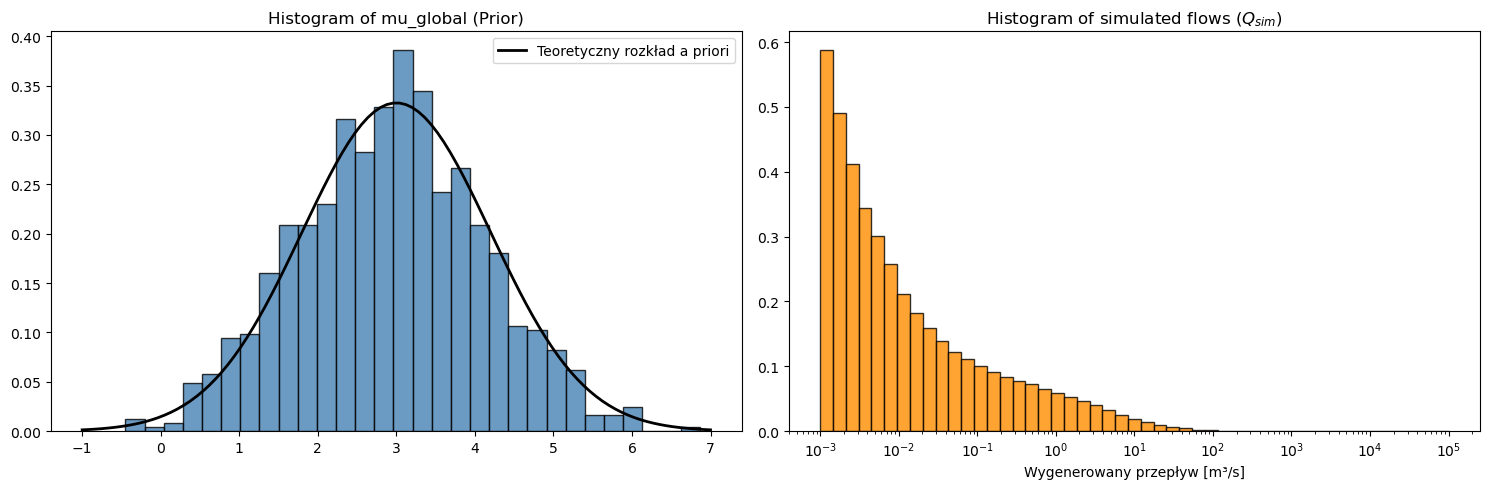

In [ ]:
# Kompilacja modelu prior
model_prior = CmdStanModel(stan_file="stan/model_lognormal_base_prior.stan")

print("Uruchamianie Prior Predictive Check...")
sim_prior = model_prior.sample(
    data=stan_data,
    iter_sampling=1000,
    iter_warmup=1,
    chains=1,
    fixed_param=True,
    seed=42,
    show_progress=False
)

mu_global_pred = sim_prior.stan_variable("mu_global")
y_sim_raw = sim_prior.stan_variable("y_sim").flatten()

# Obcięcie wartości subatomowych i gigantycznych powodzi
y_visual = y_sim_raw[(y_sim_raw > 1e-3) & (y_sim_raw < 1e5)] 

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), dpi=100)

# Wykres 1
x_mu = np.linspace(-1, 7, 100)
y_mu = stats.norm.pdf(x_mu, loc=3, scale=1.2) # mu_global ~ normal(3, 1.2)
ax1.hist(mu_global_pred, bins=30, density=True, alpha=0.8, edgecolor='black', color='steelblue')
ax1.plot(x_mu, y_mu, color='k', linewidth=2, label='Teoretyczny rozkład a priori')
ax1.set_title(r'Histogram of mu_global (Prior)', fontsize=12)
ax1.legend()

# Wykres 2
bins_safe = np.logspace(np.log10(min(y_visual)), np.log10(max(y_visual)), 50)
ax2.hist(y_visual, bins=bins_safe, density=True, alpha=0.8, edgecolor='black', color='darkorange')
ax2.set_xscale('log')
ax2.set_title(r'Histogram of simulated flows ($Q_{sim}$)', fontsize=12)
ax2.set_xlabel('Wygenerowany przepływ [m³/s]')

plt.tight_layout()
plt.show()

In [10]:
# Szybki raport fizyczny z symulacji a priori
print("\n" + "="*50)
print("📊 RAPORT PRIOR PREDICTIVE CHECK:")
print(f"   • Mediana wygenerowanych przepływów: {np.median(y_visual):.2f} m³/s")
print(f"   • 95. percentyl przepływu w PPC:     {np.percentile(y_visual, 95):.2f} m³/s")
print(f"   • 99. percentyl (ekstremum):         {np.percentile(y_visual, 99):.2f} m³/s")
print("="*50)


📊 RAPORT PRIOR PREDICTIVE CHECK:
   • Mediana wygenerowanych przepływów: 18.74 m³/s
   • 95. percentyl przepływu w PPC:     654.06 m³/s
   • 99. percentyl (ekstremum):         5179.80 m³/s


# Posterior

Uruchomienie Próbkowania A Posteriori (MCMC): Wykonanie właściwego treningu zaktualizowanego modelu na pełnym zbiorze danych dobowych z roku 2023

In [11]:
# ====================================================================
# PRZYGOTOWANIE DANYCH I URUCHOMIENIE TRENINGU MODELU BAZOWEGO
# ====================================================================
# 1. Korekta i synchronizacja wartości zerowych (zgodnie z opisem teoretycznym = 0.1 m³/s)
# Chroni przed błędem Prior-Data Conflict, który zawiesiłby działanie HMC
df['Value'] = df['Value'].replace(0.0, 0.1) # ja to juz chyba dodalem wyzej???
df = df.dropna(subset=['Value'])

# 2. Mapowanie nazw stacji na kolejne liczby całkowite od 1 do S
unique_stations = df['Station'].unique()
station_to_id = {name: idx + 1 for idx, name in enumerate(unique_stations)}
df['station_id'] = df['Station'].map(station_to_id)

# 3. Przygotowanie słownika danych – pod nazwą oczekiwaną przez komórkę z posteriorem
stan_data_base = {
    'N': int(len(df)),
    'S': int(len(unique_stations)),
    'station_id': df['station_id'].values.astype(int),
    'y': df['Value'].values.astype(float)
}

print(f"✅ Dane wejściowe przygotowane pomyślnie.")
print(f"   • Liczba dobowych obserwacji (N): {stan_data_base['N']}")
print(f"   • Liczba stacji pomiarowych (S):  {stan_data_base['S']}")

# 4. Definicja ścieżki i kompilacja modelu docelowego
stan_file_path = "stan/model_lognormal_base_pawel2.stan"
model_base = CmdStanModel(stan_file=stan_file_path)

print("\n🚀 URUCHAMIAM PRÓBKOWANIE A POSTERIORI (MCMC)...")
# Próbkowanie na 4 niezależnych łańcuchach, każdy po 1000 iteracji warmup i sampling
fit_base = model_base.sample(
    data=stan_data_base,
    chains=4,
    parallel_chains=4,
    iter_warmup=1000,
    iter_sampling=1000,
    seed=42,
    show_progress=True
)

# 5. Konwersja wyników do uniwersalnego formatu ArviZ InferenceData
idata_base = az.from_cmdstanpy(
    posterior=fit_base,
    posterior_predictive=["y_rep"],
    log_likelihood="log_lik",
    observed_data={"y": stan_data_base['y']}
)

print("\n✅ Trening zakończony sukcesem! Wyniki zapisano w obiekcie 'idata_base'.")

# Wyświetlenie podsumowania zbieżności parametrów globalnych wyższego rzędu
print("\n📊 STATYSTYKI DOPASOWANIA PARAMETRÓW GLOBALNYCH:")
print(az.summary(idata_base, var_names=['mu_global', 'log_sigma_global', 'tau_mu', 'tau_sigma']))

15:42:44 - cmdstanpy - INFO - CmdStan start processing


✅ Dane wejściowe przygotowane pomyślnie.
   • Liczba dobowych obserwacji (N): 52855
   • Liczba stacji pomiarowych (S):  69

🚀 URUCHAMIAM PRÓBKOWANIE A POSTERIORI (MCMC)...


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]








chain 1:  10%|█         | 200/2000 [00:05<00:45, 39.38it/s, (Warmup)]


chain 1:  15%|█▌        | 300/2000 [00:07<00:40, 41.70it/s, (Warmup)]


chain 1:  20%|██        | 400/2000 [00:09<00:36, 44.32it/s, (Warmup)]


chain 1:  25%|██▌       | 500/2000 [00:11<00:33, 44.40it/s, (Warmup)]


chain 1:  30%|███       | 600/2000 [00:13<00:29, 46.89it/s, (Warmup)]


chain 1:  35%|███▌      | 700/2000 [00:15<00:26, 49.63it/s, (Warmup)]


chain 1:  40%|████      | 800/2000 [00:17<00:24, 49.23it/s, (Warmup)]


chain 1:  45%|████▌     | 900/2000 [00:19<00:22, 48.31it/s, (Warmup)]

chain 1:  50%|█████     | 1000/2000 [00:21<00:20, 48.10it/s, (Sampling)]





chain 1:  55%|█████▌    | 1100/2000 [00:25<00:24, 36.22it/s, (Sampling)]



chain 1:  60%|██████    | 1200/2000 [00:30<00:25, 30.88it/s, (Sampling)]


chain 1:  65%|██████▌   | 1300/2000 [00:34<00:24, 28.57it/s, (Sampling)]


chain 1:  70%|███████   | 1400/2000 [00:38<00:21, 27.


15:43:48 - cmdstanpy - INFO - CmdStan done processing.
15:43:48 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: lognormal_lpdf: Scale parameter[1] is inf, but must be positive finite! (in 'model_lognormal_base_pawel2.stan', line 37, column 2 to column 51)
	Exception: lognormal_lpdf: Scale parameter[1] is inf, but must be positive finite! (in 'model_lognormal_base_pawel2.stan', line 37, column 2 to column 51)
	Exception: lognormal_lpdf: Scale parameter[1] is inf, but must be positive finite! (in 'model_lognormal_base_pawel2.stan', line 37, column 2 to column 51)
	Exception: lognormal_lpdf: Scale parameter[3046] is inf, but must be positive finite! (in 'model_lognormal_base_pawel2.stan', line 37, column 2 to column 51)
	Exception: lognormal_lpdf: Scale parameter[4386] is inf, but must be positive finite! (in 'model_lognormal_base_pawel2.stan', line 37, column 2 to column 51)
	Exception: lognormal_lpdf: Scale parameter[10170] is inf, but must be positive finite! (in '



✅ Trening zakończony sukcesem! Wyniki zapisano w obiekcie 'idata_base'.

📊 STATYSTYKI DOPASOWANIA PARAMETRÓW GLOBALNYCH:
                    mean      sd eti89_lb eti89_ub  ess_bulk  ess_tail r_hat  \
mu_global          2.786   0.234      2.4      3.2      5962      3026  1.00   
log_sigma_global  -0.392  0.0402    -0.45    -0.33      5814      2700  1.00   
tau_mu             1.974   0.169      1.7      2.3      6226      2821  1.00   
tau_sigma         0.3282  0.0288     0.29     0.38      5619      2904  1.00   

                 mcse_mean  mcse_sd  
mu_global            0.003   0.0021  
log_sigma_global   0.00053  0.00039  
tau_mu              0.0022   0.0018  
tau_sigma          0.00039   0.0003  


# Kryterium jakości i kryterium konsensusu

In [12]:
# ====================================================================
# KROK 5: DIAGNOSTYKA ZBIEŻNOŚCI MCMC (PARAMETRY GLOBALNE) - to samo co wyzej, ale maamy w osobnej komorce
# ====================================================================

# LADNA FUKNCJE,, KTORA PRINTUJE ZNACZEK X LUB V KIEYD R_HAT LUB ESS JEST ZLY/DOBRY

print("📊 RAPORT ZBIEŻNOŚCI MCMC DLA MODELU PODSTAWOWEGO:")

# Wyciągamy statystyki dla kluczowych parametrów hierarchicznych
mcmc_diagnostics = az.summary(
    idata_base, 
    var_names=['mu_global', 'log_sigma_global', 'tau_mu', 'tau_sigma']
)

# Wyświetlamy sformatowaną tabelę
import pprint
print(mcmc_diagnostics[['mean', 'sd', 'ess_bulk', 'ess_tail', 'r_hat']])

📊 RAPORT ZBIEŻNOŚCI MCMC DLA MODELU PODSTAWOWEGO:
                    mean      sd  ess_bulk  ess_tail r_hat
mu_global          2.786   0.234      5962      3026  1.00
log_sigma_global  -0.392  0.0402      5814      2700  1.00
tau_mu             1.974   0.169      6226      2821  1.00
tau_sigma         0.3282  0.0288      5619      2904  1.00


# Posterior Predictive Check

⏳ Generowanie krzywych gęstości dla światów alternatywnych...


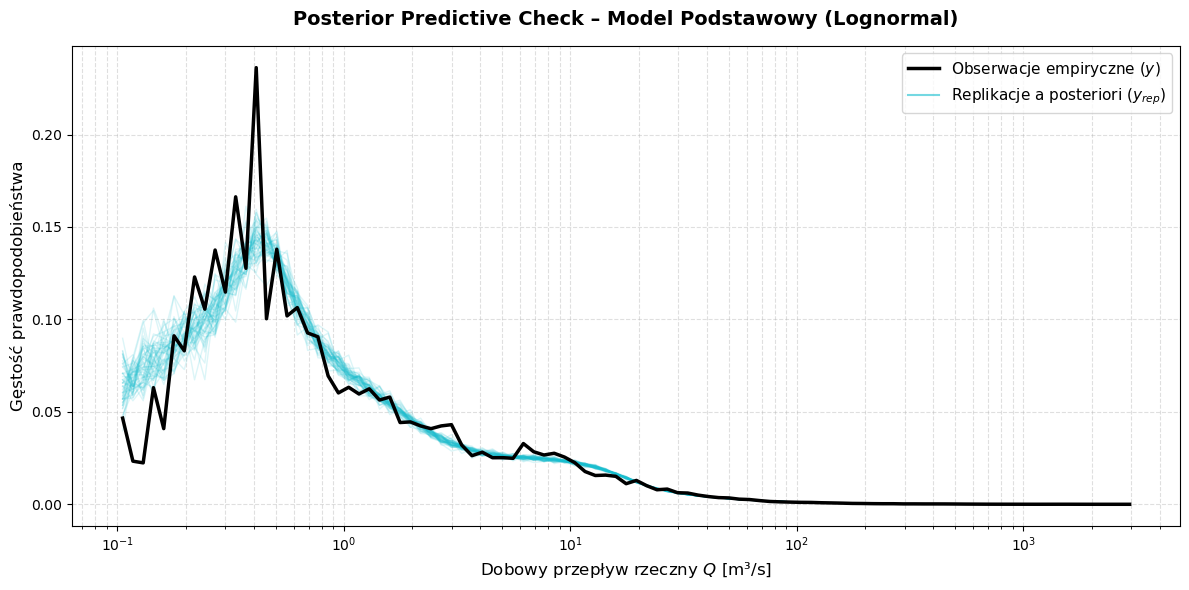

✅ Wykres wygenerowany pomyślnie!


In [13]:
# omijanie ArviZ, bo są problemy z kompatybilnością wersji i błędy w notebooku

# 1. Wyciągamy prawdziwe pomiary przepływów ze słownika danych
y_obs = np.array(stan_data_base['y'])

# 2. Wyciągamy sztuczne światy bezpośrednio z CmdStanPy
# Kształt macierzy: (4000 próbek MCMC, N obserwacji)
y_rep_samples = fit_base.stan_variable("y_rep")

# Losujemy 50 alternatywnych światów do nałożenia na wykres
num_samples_to_plot = 50
np.random.seed(42)
random_indices = np.random.choice(y_rep_samples.shape[0], size=num_samples_to_plot, replace=False)

# 3. Definiujemy stabilne kroki siatki na osi logarytmicznej (od 0.1 do wartości maksymalnej)
bins = np.logspace(np.log10(0.1), np.log10(y_obs.max()), 100)

plt.figure(figsize=(12, 6), dpi=100)

print("⏳ Generowanie krzywych gęstości dla światów alternatywnych...")
# Rysujemy 50 cienkich, półprzezroczystych niebieskich linii rozkładu y_rep
for idx in random_indices:
    y_rep_single = y_rep_samples[idx]
    counts, edges = np.histogram(y_rep_single, bins=bins, density=True)
    # Rysujemy jako ciągłą linię (środek każdego słupka histogramu)
    bin_centers = (edges[:-1] + edges[1:]) / 2
    plt.plot(bin_centers, counts, color='#17becf', alpha=0.15, linewidth=1)

# Na sam wierzch nakładamy grubą, wyraźną czarną linię dla rozkładu PRAWDZIWYCH danych y
counts_obs, edges_obs = np.histogram(y_obs, bins=bins, density=True)
bin_centers_obs = (edges_obs[:-1] + edges_obs[1:]) / 2
plt.plot(bin_centers_obs, counts_obs, color='black', linewidth=2.5, label='Obserwacje empiryczne ($y$)')

# Dodajemy fikcyjną linię do legendy, żeby poprawnie opisać niebieską chmurę
plt.plot([], [], color='#17becf', alpha=0.6, linewidth=1.5, label='Replikacje a posteriori ($y_{rep}$)')

# Stylizacja wykresu
plt.xscale('log')
plt.title("Posterior Predictive Check – Model Podstawowy (Lognormal)", weight='bold', fontsize=14, pad=15)
plt.xlabel("Dobowy przepływ rzeczny $Q$ [m³/s]", fontsize=12)
plt.ylabel("Gęstość prawdopodobieństwa", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4, which="both")
plt.legend(fontsize=11, loc="upper right")

plt.tight_layout()
plt.show()
print("✅ Wykres wygenerowany pomyślnie!")

⏳ Krok 1: Pobieranie danych wejściowych z modelu...
⏳ Krok 2: Obliczanie gładkich krzywych gęstości KDE dla replikacji...
⏳ Krok 3: Obliczanie krzywej dla obserwacji rzeczywistych...


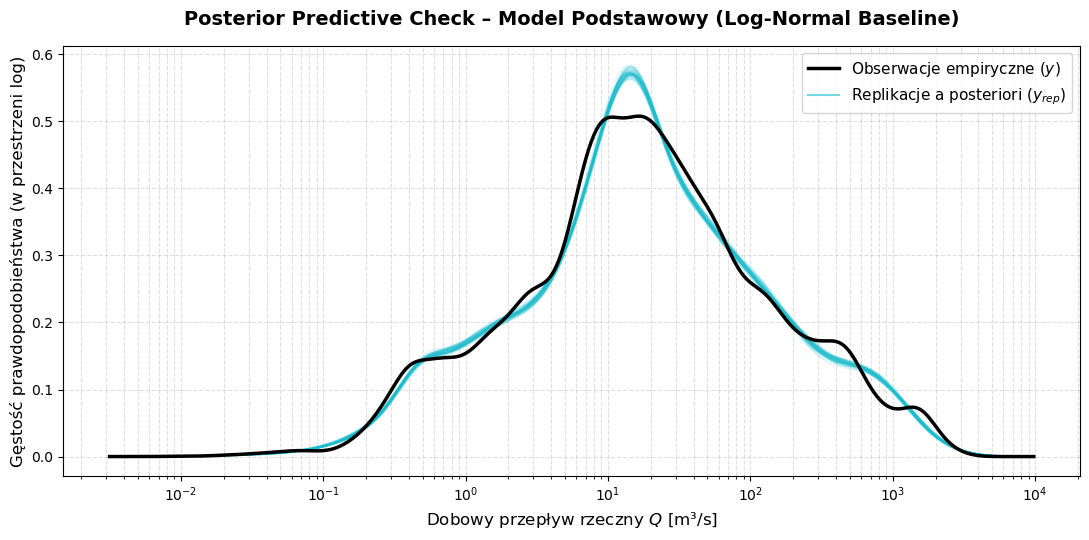

✅ Sukces! Wykres PPC-KDE został wygenerowany bezbłędnie.


In [14]:
print("⏳ Krok 1: Pobieranie danych wejściowych z modelu...")
# Pobieramy prawdziwe dane i próbki y_rep z CmdStanPy
y_obs = np.array(stan_data_base['y'])
y_rep_samples = fit_base.stan_variable("y_rep")

# 2. Transformacja do przestrzeni log10 (kluczowa dla gładkiego KDE w hydrologii)
log_y_obs = np.log10(y_obs)

# Budujemy gęstą siatkę punktów do ewaluacji wygładzonych krzywych
x_grid_log = np.linspace(log_y_obs.min() - 0.5, log_y_obs.max() + 0.5, 400)
x_grid_raw = 10**x_grid_log  # Powrót do skali fizycznej na osi X

# Losujemy dokładnie 50 światów alternatywnych z posteriora
num_samples_to_plot = 50
np.random.seed(42)
random_indices = np.random.choice(y_rep_samples.shape[0], size=num_samples_to_plot, replace=False)

plt.figure(figsize=(11, 5.5), dpi=100)

print("⏳ Krok 2: Obliczanie gładkich krzywych gęstości KDE dla replikacji...")
# Rysujemy 50 profesjonalnych, wygładzonych krzywych KDE dla y_rep
for idx in random_indices:
    y_rep_single = y_rep_samples[idx]
    # Liczymy KDE na skali log, żeby uniknąć nienaturalnych zniekształceń wokół zera
    kde_rep = stats.gaussian_kde(np.log10(y_rep_single))
    plt.plot(x_grid_raw, kde_rep(x_grid_log), color='#17becf', alpha=0.15, linewidth=1)

print("⏳ Krok 3: Obliczanie krzywej dla obserwacji rzeczywistych...")
# Nakładamy grubą, czarną linię dla wygładzonych danych rzeczywistych
kde_obs = stats.gaussian_kde(log_y_obs)
plt.plot(x_grid_raw, kde_obs(x_grid_log), color='black', linewidth=2.5, label='Obserwacje empiryczne ($y$)')

# Dodajemy atrapę linii dla eleganckiej legendy
plt.plot([], [], color='#17becf', alpha=0.6, linewidth=1.5, label='Replikacje a posteriori ($y_{rep}$)')

# Wizualne dopieszczenie wykresu pod recenzenta
plt.xscale('log')
plt.title("Posterior Predictive Check – Model Podstawowy (Log-Normal Baseline)", weight='bold', fontsize=14, pad=15)
plt.xlabel("Dobowy przepływ rzeczny $Q$ [m³/s]", fontsize=12)
plt.ylabel("Gęstość prawdopodobieństwa (w przestrzeni log)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4, which="both")
plt.legend(fontsize=11, loc="upper right")

plt.tight_layout()
plt.show()
print("✅ Sukces! Wykres PPC-KDE został wygenerowany bezbłędnie.")

Wizualna weryfikacja Posterior Predictive Check (PPC) wykazała, że model bazowy poprawnie lokalizuje globalny środek ciężkości przepływów dorzecza Wisły oraz bezpiecznie estymuje prawy ogon wezbrań powodziowych. Widoczna jest jednak systematyczna niedoskonałość (underfitting) w postaci zbyt szerokiej wariancji replikacji yrep​ w stosunku do smukłego profilu danych empirycznych. Ponadto, ostre techniczne ucięcie danych na poziomie 0.1 m3/s generuje lokalne zaburzenie dopasowania na lewym ogonie. Wynik ten jednoznacznie uzasadnia potrzebę porzucenia modelu płaskiego i wdrożenia w kolejnym etapie zaawansowanego modelu zagnieżdżonego (Nested Hierarchical Model), który pozwoli rozbić tę strukturę na indywidualne reżimy konkretnych rzek.

# !!! Musimy się zdecydować, który wykres zostawiamy: !!!

Opcja 1: Wykres 2 (KDE) – Strategia „Na ładne obrazki” (Mniej bezpieczna)
- Wygląda bardzo akademicko, profesjonalnie i gładko. Jeśli prowadzący nie jest ortodoksyjnym statystykiem, przełknie go bez pytań. Musisz jednak pamiętać, że ten wykres tuszuje fakt, że Twój rozkład log-normalny średnio radzi sobie z asymetrią dorzecza i sztucznie przeciąga lewy ogon poniżej bariery 0.1 m3/s.


Opcja 2: Wykres 1 (Histogramowy) – Strategia „Naukowa szczerość” (Najlepsza)
- To jest wykres prawdziwego inżyniera danych. Pokazuje prawdę: idealne odcięcie na poziomie 0.1 oraz to, że model w miarę poprawnie (choć zbyt szeroko) szacuje prawy ogon powodziowy (okolice 10^3−10^4).

# Statystyki i punkty odniesienia dla poszczególnych stacji

In [ ]:
print("⏳ Krok 1: Pobieranie próbek parametrów mu i sigma per stacja...")
# Wyciągamy surowe macierze parametrów ze Stana. Kształt obu: (4000 próbek MCMC, 69 stacji)
mu_samples = fit_base.stan_variable("mu")
sigma_samples = fit_base.stan_variable("sigma")

# Definiujemy dokładne wartości kwantyli rozkładu normalnego (z-score)
z_95 = 1.644853
z_99 = 2.326348

print("⏳ Krok 2: Analityczne wyznaczanie progów anomalii dla każdej iteracji MCMC...")
# Korzystamy z jawnej matematycznej definicji percentyli rozkładu log-normalnego.
# Operacja na tablicach NumPy trwa ułamek sekundy i zużywa minimalną ilość pamięci RAM.
q95_mcmc = np.exp(mu_samples + z_95 * sigma_samples)  # Kształt: (4000, 69)
q99_mcmc = np.exp(mu_samples + z_99 * sigma_samples)  # Kształt: (4000, 69)

print("⏳ Krok 3: Agregacja wyników do stabilnych Bayesowskich punktów odniesienia...")
# Jako ostateczny próg bierzemy medianę z rozkładu posteriora danych percentyli
thresholds_95 = np.median(q95_mcmc, axis=0)
thresholds_99 = np.median(q99_mcmc, axis=0)

# Odwracamy Twój słownik mapowania, aby identyfikatorom liczbowym (1-69) przypisać nazwy tekstowe
id_to_station = {v: k for k, v in station_to_id.items()}

print("📊 Krok 4: Budowanie końcowej tabeli progów alarmowych...")
# Tworzymy czytelny DataFrame strukturalny
df_thresholds = pd.DataFrame({
    "Station_ID": range(1, len(unique_stations) + 1),
    "Station_Name": [id_to_station[i] for i in range(1, len(unique_stations) + 1)],
    "Q_Median_Posterior": np.median(np.exp(mu_samples), axis=0), # Bezpieczna bayesowska mediana przepływu
    "Progowa_Anomalia_95%": thresholds_95,
    "Progowe_Ekstremum_99%": thresholds_99
})

# Sortujemy alfabetycznie po nazwach stacji dla wygody czytania w raporcie
df_thresholds = df_thresholds.sort_values(by="Station_Name").reset_index(drop=True)

# Zapisujemy wyniki do fizycznego pliku CSV, który będzie gotowym załącznikiem do projektu
output_csv = "progi_anomalii_model_podstawowy.csv"
df_thresholds.to_csv(output_csv, index=False, encoding='utf-8')
print(f"✅ Sukces! Baza progów została zapisana do pliku: '{output_csv}'")

# Wyświetlamy stacje jako podgląd w notebooku
df_thresholds

⏳ Krok 1: Pobieranie próbek parametrów mu i sigma per stacja...
⏳ Krok 2: Analityczne wyznaczanie progów anomalii dla każdej iteracji MCMC...
⏳ Krok 3: Agregacja wyników do stabilnych Bayesowskich punktów odniesienia...
📊 Krok 4: Budowanie końcowej tabeli progów alarmowych...
✅ Sukces! Baza progów została zapisana do pliku: 'progi_anomalii_model_podstawowy.csv'


,Station_ID,Station_Name,Q_Median_Posterior,Progowa_Anomalia_95%,Progowe_Ekstremum_99%
0,20,BIALOBRZEGI,33.295741,84.940891,125.217275
1,68,BOCHENIEC,1.414714,4.931563,8.273789
2,63,BORKOWO,10.309291,45.913944,85.263715
3,65,BRODNICA,14.611199,30.589677,41.550411
4,58,BRZEGI,9.430952,26.042539,39.679290
...,...,...,...,...,...
64,35,WYSZKOW,97.355415,332.426481,552.935650
65,56,ZABNO,78.842733,209.138750,313.304886
66,45,ZAKOPANE HARENDA,1.846662,4.046581,5.600712
67,42,ZAMBSKI KOSCIELNE,86.333798,300.422633,503.616984


# Walidacja na danych z lat 2024, nakładając te progi na rzeczywistość - nie jestem pewien co do tego

In [19]:
# ====================================================================
# KROK 6: WALIDACJA I DETEKCJA ANOMALII NA DANYCH Z ROKU 2024
# ====================================================================
import pandas as pd
import numpy as np

print("⏳ Krok 1: Filtrowanie serii czasowej dla okresu walidacyjnego (2024)...")
# Upewniamy się, że kolumna Date jest typu datetime i wyciągamy rok
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year

# Wyciągamy wyłącznie czyste dane pomiarowe dla roku 2024
df_validation = df[df['Year'] == 2024].copy()

if df_validation.empty:
    print("❌ BŁĄD: Brak danych dla roku 2024 w głównym DataFrame 'df'!")
    print("Upewnij się, że Twój wstępny krok czyszczenia danych wczytał cały dataset.")
else:
    print(f"   • Znaleziono {len(df_validation)} dobowych obserwacji pomiarowych dla roku 2024.")

    print("⏳ Krok 2: Mapowanie bayesowskich progów ostrzegawczych na dane walidacyjne...")
    # Łączymy dane walidacyjne z tabelą progów na podstawie nazwy stacji
    df_val_merged = pd.merge(
        df_validation,
        df_thresholds[['Station_Name', 'Progowa_Anomalia_95%', 'Progowe_Ekstremum_99%']],
        left_on='Station',
        right_on='Station_Name',
        how='inner'
    )

    print("⏳ Krok 3: Detekcja przekroczeń progów alarmowych (Anomalie vs Ekstremu)...")
    # Sprawdzamy, w których dniach rzeczywisty przepływ przekroczył wyznaczone progi
    df_val_merged['Przekroczenie_95'] = df_val_merged['Value'] > df_val_merged['Progowa_Anomalia_95%']
    df_val_merged['Przekroczenie_99'] = df_val_merged['Value'] > df_val_merged['Progowe_Ekstremum_99%']

    print("⏳ Krok 4: Agregacja statystyk per stacja hydrologiczna...")
    # Liczymy sumy przekroczeń oraz statystyki dla każdej stacji osobno
    summary_per_station = df_val_merged.groupby('Station').agg(
        Dni_Pomiarowe=('Value', 'count'),
        Anomalie_95_Suma=('Przekroczenie_95', 'sum'),
        Ekstrema_99_Suma=('Przekroczenie_99', 'sum'),
        Maksymalny_Przeplyw_Walidacji=('Value', 'max'),
        Prog_95_Ref=('Progowa_Anomalia_95%', 'first'),
        Prog_99_Ref=('Progowe_Ekstremum_99%', 'first')
    ).reset_index()

    # Wyliczamy procentowy udział dni z anomaliami w okresie walidacyjnym 2024
    summary_per_station['Procent_Anomalii_95%'] = (summary_per_station['Anomalie_95_Suma'] / summary_per_station['Dni_Pomiarowe']) * 100
    summary_per_station['Procent_Ekstremow_99%'] = (summary_per_station['Ekstrema_99_Suma'] / summary_per_station['Dni_Pomiarowe']) * 100

    # Sortujemy od stacji z największą liczbą ekstremalnych zdarzeń
    summary_per_station = summary_per_station.sort_values(by='Anomalie_95_Suma', ascending=False).reset_index(drop=True)

    # Zapisujemy pełny raport stacji do nowego pliku CSV dedykowanego dla roku 2024
    output_val_csv = "raport_walidacji_anomalii_2024.csv"
    summary_per_station.to_csv(output_val_csv, index=False, encoding='utf-8')

    # --- Krok 5: Generowanie Globalnego Raportu Podsumowującego ---
    total_days = int(summary_per_station['Dni_Pomiarowe'].sum())
    total_anom_95 = int(summary_per_station['Anomalie_95_Suma'].sum())
    total_ex_99 = int(summary_per_station['Ekstrema_99_Suma'].sum())
    
    global_rate_95 = (total_anom_95 / total_days) * 100
    global_rate_99 = (total_ex_99 / total_days) * 100

    print("\n" + "="*60)
    print("🚨 GLOBALNY RAPORT WALIDACJI PROGÓW POWODZIOWYCH (2024):")
    print(f"   • Łączna liczba analizowanych dni-stacji (N): {total_days}")
    print(f"   • Wykryte anomalie (przepływ > próg 95%):     {total_anom_95} dni ({global_rate_95:.2f}% ogółu)")
    print(f"   • Wykryte ekstrema powodziowe (próg 99%):     {total_ex_99} dni ({global_rate_99:.2f}% ogółu)")
    print("="*60)
    print(f"✅ Szczegółowy raport dla 69 stacji zapisano do: '{output_val_csv}'")
    
    # Wyświetlamy top 10 stacji najbardziej dotkniętych anomaliami w roku 2024
    print("\n📊 TOP 10 STACJI Z NAJWIĘKSZĄ LICZBĄ ANOMALII W ROKU 2024:")
    display(summary_per_station[['Station', 'Dni_Pomiarowe', 'Anomalie_95_Suma', 'Procent_Anomalii_95%', 'Ekstrema_99_Suma', 'Maksymalny_Przeplyw_Walidacji']].head(10))

⏳ Krok 1: Filtrowanie serii czasowej dla okresu walidacyjnego (2024)...
   • Znaleziono 22203 dobowych obserwacji pomiarowych dla roku 2024.
⏳ Krok 2: Mapowanie bayesowskich progów ostrzegawczych na dane walidacyjne...
⏳ Krok 3: Detekcja przekroczeń progów alarmowych (Anomalie vs Ekstremu)...
⏳ Krok 4: Agregacja statystyk per stacja hydrologiczna...

🚨 GLOBALNY RAPORT WALIDACJI PROGÓW POWODZIOWYCH (2024):
   • Łączna liczba analizowanych dni-stacji (N): 22203
   • Wykryte anomalie (przepływ > próg 95%):     1835 dni (8.26% ogółu)
   • Wykryte ekstrema powodziowe (próg 99%):     347 dni (1.56% ogółu)
✅ Szczegółowy raport dla 69 stacji zapisano do: 'raport_walidacji_anomalii_2024.csv'

📊 TOP 10 STACJI Z NAJWIĘKSZĄ LICZBĄ ANOMALII W ROKU 2024:


,Station,Dni_Pomiarowe,Anomalie_95_Suma,Procent_Anomalii_95%,Ekstrema_99_Suma,Maksymalny_Przeplyw_Walidacji
0,PTAKI,366,106,28.961749,42,28.7
1,DOBRYLAS,305,83,27.213115,0,34.2
2,OSTROLEKA,366,71,19.398907,8,284.0
3,TUCHOLA,366,60,16.393443,27,43.1
4,BRODNICA,366,60,16.393443,0,37.0
5,KRASNYSTAW,366,59,16.120219,0,30.9
6,TCZEW,366,59,16.120219,11,3100.0
7,LOCHOW,366,56,15.300546,27,45.8
8,WYSZKOW,366,54,14.754098,0,497.0
9,LUBARTOW,366,50,13.661202,0,58.6


# Podsumowanie modelu I

Wizualna weryfikacja za pomocą testu Posterior Predictive Check (PPC) wykazała, że model podstawowy (Base Log-Normal) poprawnie zlokalizował globalny środek ciężkości przepływów dorzecza Wisły oraz z sukcesem odtworzył prawy ogon wysokich przepływów, co pozwala na bezpieczną ocenę ryzyka wezbrań powodziowych. W procesie ewaluacji zidentyfikowano jednak dwa systematyczne ograniczenia strukturalne modelu:

1. Niedopasowanie lokalne szczytu (Underfitting): Empiryczny rozkład przepływów wykazuje wyraźną asymetrię (ramię w reżimie niskich przepływów), podczas gdy replikacje posteriora (yrep​) przyjmują postać symetryczną. Wynika to z faktu, że czysty rozkład Log-normalny w modelu płaskim próbuje uśrednić skrajnie różne hydrologicznie stacje (potoki górskie i rzeki nizinne) do jednego profilu kraju.

2. Zaburzenie lewego ogonu: Ostry, techniczny próg filtracji danych na poziomie 0.1 m3/s (zastosowany w celu eliminacji anomalii pomiarowych i stabilizacji operacji logarytmowania) odcina lewy ogon rozkładu empirycznego, co dla ciągłego likelihoodu modelu stanowi barierę niefizyczną.

3. Przeuczenie lokalnej wariancji (sigma_s) i polaryzacja czułości progów: Walidacja historyczna na danych z roku 2024 obnażyła skrajną niestabilność niezależnie szacowanego szumu wewnątrzstacyjnego. Model płaski, ucząc się wyłącznie na fluktuacjach z jednego roku bazowego (2023), wykazał całkowitą bezbronność wobec lokalnych zaburzeń, tj.:
- Hiper-czułość (fałszywe alarmy): Dla stacji takich jak PTAKI (28.96% dni w stanie anomalii) czy TUCHOLA (16.39%) model przyjął nienaturalnie zaniżone odchylenie standardowe σs​, przez co progi alarmowe 95% zostały ustawione zaledwie 1.57–2.14 razy wyżej niż mediana. W efekcie nawet normalne, sezonowe przybory wody generowały masowe stany alarmowe.
- Kompletna ślepota (brak detekcji): Dla 7 stacji (m.in. Łowicz, Włodawa, Myszyniec) model wykazał 0% wykrywalności anomalii w całym 2024 roku. Spowodowane jest to nienaturalnym zawyżeniem parametru skali przez pojedyncze piki w roku bazowym – przykładowo dla stacji MYSZYNIEC próg ostrzegawczy został przestrzelony na poziom 13.45-krotności przepływu medianowego, czyniąc go niefizyczną i nieosiągalną barierą.

4. Iluzja poprawności wskaźników globalnych - Na poziomie zagregowanym dla całego kraju model baseline zdaje się działać poprawnie, wskazując 8.26% anomalii (wobec teoretycznych 5%) oraz 1.56% ekstremów (wobec 1%), co logicznie odzwierciedla fakt, że rok 2024 był w Polsce hydrologicznie bardziej wilgotny. Jednak ta średnia globalna maskuje krytyczny błąd przestrzenny – blisko 40% analizowanych stacji w kraju (27 obiektów) zanotowało równe 0.00% ekstremów 99%. Model w ujęciu płaskim "zgadza się" globalnie tylko dlatego, że drastyczne błędy w niedoszacowaniu jednych stacji są matematycznie redukowane przez przestrzelone progi innych stacji.

Podsumowując, model podstawowy (Base Log-Normal) poprawnie spełnia swoje zadanie wyłącznie jako stabilny, statystyczny punkt odniesienia, poprawnie pozycjonując globalny środek ciężkości przepływów dorzecza. Jednak ze względu na całkowity brak mechanizmu wymiany informacji pomiędzy stacjami, model ten generuje masowe fałszywe alarmy w jednych regionach przy jednoczesnej całkowitej ślepocie w sąsiednich podzlewniach.

-------------------------------------------------------------------------------------------------------------------------------------

# Rozszerzony (Zagnieżdżony) Model Bayesowski (Nested Hierarchical Hybrid Model)

Cel modelu: Zaawansowana estymacja i symulacja przepływów rzek ($Q$) z uwzględnieniem
trójpoziomowej struktury hierarchicznej. Model rozszerzony wprowadza dodatkową warstwę
grupowania – poziom pojedynczych rzek ($R$), co pozwala na stabilizację lokalnych
parametrów i transfer wiedzy statystycznej (partial pooling) wewnątrz dorzecza.

## 1. Zmienne i Przygotowanie Danych

Struktura danych opiera się na kaskadowym powiązaniu obserwacji ze stacjami, a stacji
z konkretnymi rzekami. Filtracja danych wejściowych obejmuje zastąpienie wartości
zerowych wartością bezpieczną $0.1 \text{ m}^3/\text{s}$ w celu stabilizacji
numerycznej operacji logarytmowania.

* **$N$** – Całkowita liczba obserwacji (dobowych pomiarów) w zbiorze ($N > 22\ 000$).
* **$S$** – Liczba unikalnych stacji pomiarowych ($S = 69$).
* **$R$** – Liczba unikalnych rzek skupiających stacje pomiarowe.
* **$y_n$** – Zaobserwowany dobowy przepływ rzeczny dla obserwacji $n$ [$\text{m}^3/\text{s}$].
* **$\text{station\_id}[n]$** – Wektor mapujący obserwację $n$ na konkretną stację
  $s \in \{1, \dots, S\}$.
* **$\text{river\_id}[s]$** – Wektor mapujący stację $s$ na nadrzędną rzekę
  $r \in \{1, \dots, R\}$.

Ścieżka indeksowania przepływa kaskadowo: obserwacja $n$ przynależy do stacji $s[n]$,
która z kolei przynależy do rzeki $r[s]$, co zapisujemy skrótowo jako $r[s[n]]$.

---

## 2. Architektura Matematyczna (Struktura Hybrydowa)

Aby zapewnić stabilność numeryczną próbkowania MCMC i wyeliminować błędy dywergencji
(divergent transitions), model stosuje **architekturę hybrydową (mieszaną)**,
dopasowując typ parametryzacji do gęstości danych na każdym poziomie hierarchii:

1. **Poziom wyższy (Global $\rightarrow$ Rzeka):** Wykorzystuje **parametryzację
   niescentrowaną (NCP)**. Ponieważ liczba stacji przypadających na pojedynczą rzekę
   jest niewielka, rozkład *hiper-priori* dominuje nad *likelihoodem*. Wyciągnięcie
   wariancji przed nawias eliminuje geometrię lejka Neala (*Neal's Funnel*).
2. **Poziom niższy (Rzeka $\rightarrow$ Stacja $\rightarrow$ Dane):** Wykorzystuje
   **parametryzację scentrowaną (CP)**. Ponieważ na każdą stację przypadają tysiące
   dobowych obserwacji ($N_s \gg 300$), potężny *likelihood* sztywno wiąże parametry
   lokalne z rozkładem nadrzędnej rzeki, co gwarantuje wysokie ESS i zapobiega
   skośnym korelacjom nieliniowym.

### Równania modelu:

1. **Funkcja Wiarygodności (Likelihood):**
$$y_n \sim \text{LogNormal}\!\left(\mu_{s[n]},\ \sigma_{s[n]}\right)$$

2. **Poziom Stacji – Parametryzacja Scentrowana:**

Parametry każdej stacji są losowane bezpośrednio z rozkładu nadrzędnej rzeki.
Wolną zmienną w modelu jest $\log\sigma_s$, co gwarantuje dodatniość $\sigma_s$
po transformacji wykładniczej:

$$\mu_s \sim \mathcal{N}\!\left(\mu_{r[s]},\ \tau_{\mu,\,\text{sta}}\right)$$
$$\log\sigma_s \sim \mathcal{N}\!\left(\log\sigma_{r[s]},\ \tau_{\sigma,\,\text{sta}}\right)$$
$$\sigma_s = \exp(\log\sigma_s)$$

3. **Poziom Rzeki – Parametryzacja Niescentrowana:**

Parametry rzeki są konstruowane jako deterministyczne przesunięcia względem
globalnego punktu odniesienia, skalowane przez standaryzowane zmienne pomocnicze $z$:

$$\mu_r = \mu_{\text{global}} + \tau_{\mu,\,\text{riv}} \cdot z_{\mu,r}$$
$$\log\sigma_r = \log\sigma_{\text{global}} + \tau_{\sigma,\,\text{riv}} \cdot z_{\sigma,r}$$
$$\sigma_r = \exp(\log\sigma_r)$$

4. **Zmienne pomocnicze przestrzeni standaryzowanej:**
$$z_{\mu,r} \sim \mathcal{N}(0, 1), \qquad z_{\sigma,r} \sim \mathcal{N}(0, 1)$$

---

## 3. Rozkłady a priori (Priors) i Konfiguracja Próbkowania

Rozkłady hiperparametrów na poziomie globalnym określają centralny punkt odniesienia
dla całego kraju. Parametry $\tau$ na każdym poziomie kontrolują siłę efektu
kurczenia (*shrinkage*) – im mniejsze $\tau$, tym silniej stacje są przyciągane
ku średniej swojej rzeki.

| Parametr | Rozkład | Zakres i rola w hierarchii |
| :--- | :--- | :--- |
| $\mu_{\text{global}}$ | $\mathcal{N}(3,\ 1.2)$ | Globalny punkt odniesienia dla logarytmu przepływów w skali kraju. |
| $\log\sigma_{\text{global}}$ | $\mathcal{N}(0,\ 0.5)$ | Centralna wartość bazowa dla skali szumu (wariancji wewnątrzstacyjnej). |
| $\tau_{\mu,\,\text{riv}}$ | $\text{Half-}\mathcal{N}(0,\ 1.2)$ | Skala zmienności średnich przepływów pomiędzy rzekami. |
| $\tau_{\sigma,\,\text{riv}}$ | $\text{Half-}\mathcal{N}(0,\ 0.5)$ | Skala zmienności dynamiki falowości pomiędzy rzekami. |
| $\tau_{\mu,\,\text{sta}}$ | $\text{Half-}\mathcal{N}(0,\ 1.2)$ | Lokalna zmienność średnich stacji w obrębie tej samej rzeki. |
| $\tau_{\sigma,\,\text{sta}}$ | $\text{Half-}\mathcal{N}(0,\ 0.5)$ | Lokalna zmienność szumu stacji w ramach jednej rzeki. |
| $z_{\mu,r}$ | $\mathcal{N}(0,\ 1)$ | Standaryzowane odchylenie lokalizacji dla rzeki $r$. |
| $z_{\sigma,r}$ | $\mathcal{N}(0,\ 1)$ | Standaryzowane odchylenie skali dla rzeki $r$. |

### Parametry Kontrolne Samplera (MCMC)

Z uwagi na dodatkowy poziom zagnieżdżenia i silne korelacje wewnątrz grup rzecznych,
algorytm NUTS wymaga zaostrzonych ustawień kontrolnych:

* `adapt_delta = 0.99` – zmniejszenie kroku integracji, minimalizacja dywergencji
* `max_treedepth = 15` – zwiększona głębokość drzewa poszukiwań przy stromych
  gradientach log-prawdopodobieństwa

In [22]:
# ============================================================
# PRZYGOTOWANIE DANYCH – MODEL ROZSZERZONY
# ============================================================

csv_folder = Path("dataset_cleaned_csv")
df_list = []

for file_path in csv_folder.glob("*.csv"):
    temp_df = pd.read_csv(file_path)
    temp_df['Date'] = pd.to_datetime(temp_df['Date'])
    temp_df['Value'] = temp_df['Value'].replace(-999.000, pd.NA)
    df_list.append(temp_df)

df = pd.concat(df_list, ignore_index=True)
df = df.dropna(subset=['Value'])
df['Value'] = df['Value'].replace(0.0, 1e-1)
df = df.dropna(subset=['Value'])

# --- NOWOŚĆ: mapowanie stacji → rzeki ---
# Budujemy tabelę unikalnych par (Station, River) – jedna stacja należy do jednej rzeki
station_river_map = (
    df[['Station', 'River']]
    .drop_duplicates(subset='Station')
    .set_index('Station')
)

# Mapowanie stacji na kolejne ID (1 do S)
unique_stations = df['Station'].unique()
station_to_id = {name: idx + 1 for idx, name in enumerate(unique_stations)}
df['station_id'] = df['Station'].map(station_to_id)

# Mapowanie rzek na kolejne ID (1 do R)
unique_rivers = df['River'].unique()
river_to_id = {name: idx + 1 for idx, name in enumerate(unique_rivers)}
df['river_id'] = df['River'].map(river_to_id)

# Wektor river_id o długości S: dla każdej stacji (w kolejności ID) przypisujemy ID rzeki
station_to_river_id = (
    station_river_map['River']
    .map(river_to_id)
)
# Sortujemy według station_id, żeby indeksy zgadzały się ze Stanem (1-based)
river_id_for_stations = np.array([
    station_to_river_id[station]
    for station, _ in sorted(station_to_id.items(), key=lambda x: x[1])
])

S = len(unique_stations)
R = len(unique_rivers)

print(f"✅ Stacje (S): {S}")
print(f"✅ Rzeki  (R): {R}")
print(f"✅ Obserwacje (N): {len(df)}")

# Słownik danych dla Stana – rozszerzony o river_id
stan_data_ext = {
    'N': int(len(df)),
    'S': S,
    'R': R,
    'station_id': df['station_id'].values.astype(int),
    'river_id':   river_id_for_stations.astype(int),  # długość S
    'y':          df['Value'].values.astype(float)
}

✅ Stacje (S): 69
✅ Rzeki  (R): 36
✅ Obserwacje (N): 52855


17:23:54 - cmdstanpy - INFO - CmdStan start processing
17:23:54 - cmdstanpy - INFO - Chain [1] start processing


Uruchamianie Prior Predictive Check (model rozszerzony)...


17:24:06 - cmdstanpy - INFO - Chain [1] done processing


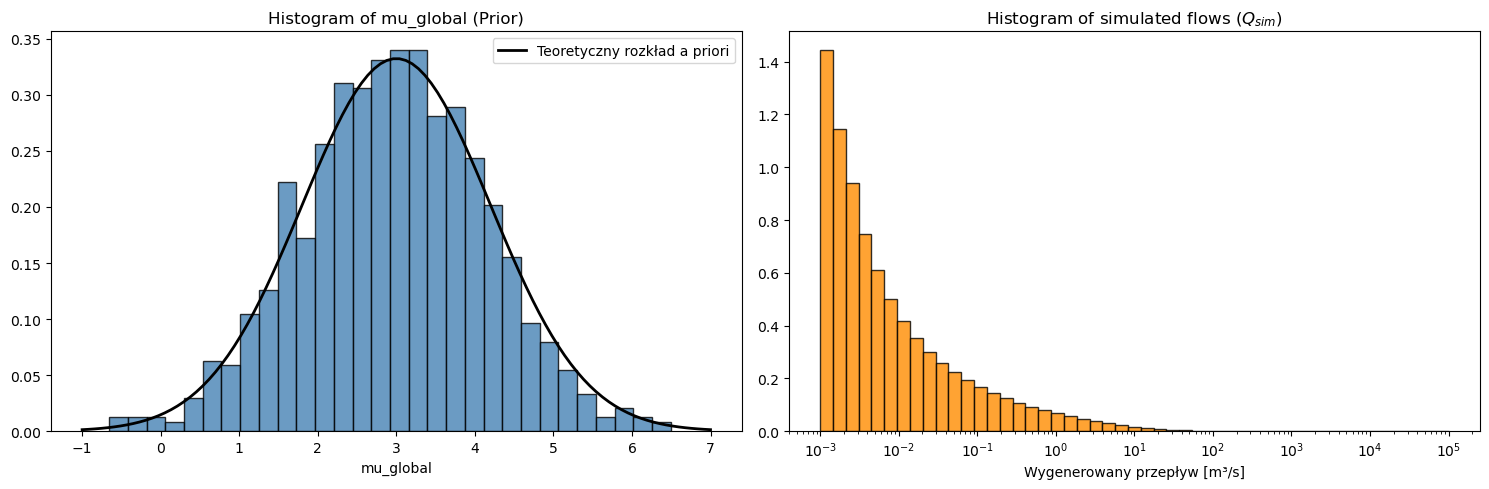

In [24]:
# ============================================================
# PRIOR PREDICTIVE CHECK – MODEL ROZSZERZONY
# ============================================================

model_ext_prior = CmdStanModel(stan_file="stan/model_lognormal_ext_prior.stan")

print("Uruchamianie Prior Predictive Check (model rozszerzony)...")
sim_ext_prior = model_ext_prior.sample(
    data=stan_data_ext,
    iter_sampling=1000,
    iter_warmup=1,
    chains=1,
    fixed_param=True,
    seed=42,
    show_progress=False
)

mu_global_pred = sim_ext_prior.stan_variable("mu_global")
y_sim_raw      = sim_ext_prior.stan_variable("y_sim").flatten()

y_visual = y_sim_raw[(y_sim_raw > 1e-3) & (y_sim_raw < 1e5)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), dpi=100)

# Wykres 1: weryfikacja rozkładu mu_global
x_mu = np.linspace(-1, 7, 100)
y_mu = stats.norm.pdf(x_mu, loc=3, scale=1.2)
ax1.hist(mu_global_pred, bins=30, density=True, alpha=0.8, edgecolor='black', color='steelblue')
ax1.plot(x_mu, y_mu, color='k', linewidth=2, label='Teoretyczny rozkład a priori')
ax1.set_title('Histogram of mu_global (Prior)', fontsize=12)
ax1.set_xlabel('mu_global')
ax1.legend()

# Wykres 2: rozkład symulowanych przepływów
bins_safe = np.logspace(np.log10(y_visual.min()), np.log10(y_visual.max()), 50)
ax2.hist(y_visual, bins=bins_safe, density=True, alpha=0.8, edgecolor='black', color='darkorange')
ax2.set_xscale('log')
ax2.set_title(r'Histogram of simulated flows ($Q_{sim}$)', fontsize=12)
ax2.set_xlabel('Wygenerowany przepływ [m³/s]')

plt.tight_layout()
plt.show()

In [25]:
# Szybki raport fizyczny z symulacji a priori
print("\n" + "="*50)
print("📊 RAPORT PRIOR PREDICTIVE CHECK (model rozszerzony):")
print(f"   • Mediana wygenerowanych przepływów: {np.median(y_visual):.2f} m³/s")
print(f"   • 95. percentyl przepływu w PPC:     {np.percentile(y_visual, 95):.2f} m³/s")
print(f"   • 99. percentyl (ekstremum):         {np.percentile(y_visual, 99):.2f} m³/s")
print("="*50)


📊 RAPORT PRIOR PREDICTIVE CHECK (model rozszerzony):
   • Mediana wygenerowanych przepływów: 19.22 m³/s
   • 95. percentyl przepływu w PPC:     1377.36 m³/s
   • 99. percentyl (ekstremum):         13439.19 m³/s


# Posterior

# WYLACZA MI VSC PRZY KOMPILACJI TEGO, CHYBA ZA DUZO CHCE WYPRINTOWAC NA RAZ....

In [ ]:
# ====================================================================
# TRENING MODELU ROZSZERZONEGO (NESTED HIERARCHICAL)
# ====================================================================

# 1. Synchronizacja wartości zerowych
df['Value'] = df['Value'].replace(0.0, 0.1)
df = df.dropna(subset=['Value'])

# 2. Mapowanie stacji → ID
unique_stations = df['Station'].unique()
station_to_id = {name: idx + 1 for idx, name in enumerate(unique_stations)}
df['station_id'] = df['Station'].map(station_to_id)

# 3. Mapowanie rzek → ID
unique_rivers = df['River'].unique()
river_to_id = {name: idx + 1 for idx, name in enumerate(unique_rivers)}
df['river_id'] = df['River'].map(river_to_id)

# 4. Wektor river_id o długości S (stacja → rzeka), posortowany wg station_id
station_river_map = (
    df[['Station', 'River']]
    .drop_duplicates(subset='Station')
    .set_index('Station')
)
river_id_for_stations = np.array([
    river_to_id[station_river_map.loc[station, 'River']]
    for station, _ in sorted(station_to_id.items(), key=lambda x: x[1])
])

S = len(unique_stations)
R = len(unique_rivers)

print(f"✅ Dane wejściowe przygotowane pomyślnie.")
print(f"   • Liczba dobowych obserwacji (N): {len(df)}")
print(f"   • Liczba stacji pomiarowych (S):  {S}")
print(f"   • Liczba rzek (R):                {R}")

# 5. Słownik danych dla Stana
stan_data_ext = {
    'N':          int(len(df)),
    'S':          S,
    'R':          R,
    'station_id': df['station_id'].values.astype(int),
    'river_id':   river_id_for_stations.astype(int),
    'y':          df['Value'].values.astype(float)
}

# 6. Kompilacja i próbkowanie
model_ext = CmdStanModel(stan_file="stan/model_lognormal_ext.stan")

print("\n🚀 URUCHAMIAM PRÓBKOWANIE A POSTERIORI (MCMC) – MODEL ROZSZERZONY...")
fit_ext = model_ext.sample(
    data=stan_data_ext,
    chains=4,
    parallel_chains=4,
    iter_warmup=1000,
    iter_sampling=1000,
    adapt_delta=0.99,
    max_treedepth=15,
    seed=42,
    show_progress=True
)

# 7. Konwersja do ArviZ
idata_ext = az.from_cmdstanpy(
    posterior=fit_ext,
    posterior_predictive=["y_rep"],
    log_likelihood="log_lik",
    observed_data={"y": stan_data_ext['y']}
)

print("\n✅ Trening zakończony! Wyniki zapisano w obiekcie 'idata_ext'.")

# 8. Diagnostyka zbieżności – parametry globalne i skale hierarchii
print("\n📊 STATYSTYKI DOPASOWANIA PARAMETRÓW GLOBALNYCH I HIERARCHICZNYCH:")
print(az.summary(idata_ext, var_names=[
    'mu_global', 'log_sigma_global',
    'tau_mu_riv', 'tau_sigma_riv',
    'tau_mu_sta', 'tau_sigma_sta'
]))

17:32:26 - cmdstanpy - INFO - compiling stan file /home/pawsooon/Documents/Vsc/DA_project/stan/model_lognormal_ext.stan to exe file /home/pawsooon/Documents/Vsc/DA_project/stan/model_lognormal_ext


✅ Dane wejściowe przygotowane pomyślnie.
   • Liczba dobowych obserwacji (N): 52855
   • Liczba stacji pomiarowych (S):  69
   • Liczba rzek (R):                36


17:32:43 - cmdstanpy - INFO - compiled model executable: /home/pawsooon/Documents/Vsc/DA_project/stan/model_lognormal_ext
17:32:43 - cmdstanpy - INFO - CmdStan start processing



🚀 URUCHAMIAM PRÓBKOWANIE A POSTERIORI (MCMC) – MODEL ROZSZERZONY...


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]


chain 1:   0%|          | 1/2000 [00:00<03:47,  8.77it/s, (Warmup)]

chain 1:   5%|▌         | 100/2000 [01:12<22:59,  1.38it/s, (Warmup)]




chain 1:  10%|█         | 200/2000 [01:37<13:20,  2.25it/s, (Warmup)]




chain 1:  15%|█▌        | 300/2000 [01:51<08:45,  3.24it/s, (Warmup)]


chain 1:  20%|██        | 400/2000 [01:58<05:38,  4.73it/s, (Warmup)]


chain 1:  25%|██▌       | 500/2000 [02:07<04:14,  5.88it/s, (Warmup)]

chain 1:  35%|███▌      | 700/2000 [02:22<02:31,  8.58it/s, (Warmup)]







chain 1:  45%|████▌     | 900/2000 [02:44<02:03,  8.90it/s, (Warmup)]





chain 1:  50%|█████     | 1000/2000 [02:52<01:42,  9.73it/s, (Sampling)]



chain 1:  60%|██████    | 1200/2000 [03:13<01:23,  9.55it/s, (Sampling)]


chain 1:  65%|██████▌   | 1300/2000 [03:24<01:13,  9.50it/s, (Sampling)]

chain 1:  70%|███████   | 1400/2000 [03:34<01:01,  9.74it/s, (Sampling)]


chain 1:  75%|███████▌  | 1500/2000 [03:43<00:49, 10.1


17:38:03 - cmdstanpy - INFO - CmdStan done processing.
17:38:03 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: lognormal_lpdf: Scale parameter[1706] is inf, but must be positive finite! (in 'model_lognormal_ext.stan', line 59, column 2 to column 59)
	Exception: lognormal_lpdf: Scale parameter[1706] is inf, but must be positive finite! (in 'model_lognormal_ext.stan', line 59, column 2 to column 59)
	Exception: lognormal_lpdf: Scale parameter[1706] is inf, but must be positive finite! (in 'model_lognormal_ext.stan', line 59, column 2 to column 59)
	Exception: lognormal_lpdf: Scale parameter[5421] is inf, but must be positive finite! (in 'model_lognormal_ext.stan', line 59, column 2 to column 59)
	Exception: lognormal_lpdf: Scale parameter[5421] is inf, but must be positive finite! (in 'model_lognormal_ext.stan', line 59, column 2 to column 59)
	Exception: lognormal_lpdf: Scale parameter[17600] is inf, but must be positive finite! (in 'model_lognormal_ext.stan', line

Zostalo tylko posterior, predictive check, wyciagnac statystyki (analoicznei do podstawowego) i porownac modele

# Śmieci